# Calibration of steady and transient models

This notebook introduces the `timflow.Calibration` class, which can be used to
calibrate steady and/or transient models to head observations.

## Contents

- [Steady calibration](#steady-calibration)
- [Transient calibration](#transient-calibration)
- [Combined calibration](#combined-calibration)
- [Calibrating on time series with constant offsets](#calibrating-on-time-series-with-constant-offsets)
- [Calibrating on time series with time shifts](#calibrating-on-time-series-with-time-shifts)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import timflow as tf
import timflow.steady as tfs
import timflow.transient as tft

## Steady calibration

In this section we will test the calibration of a steady model. First, we build a model
to represent the "truth".

In [2]:
ml_s = tfs.ModelXsection(naq=1)
river_s = tfs.XsectionMaq(
    ml_s,
    x1=-np.inf,
    x2=0.0,
    kaq=[10.0],
    z=[0.1, 0, -10],
    c=[1e-4],
    npor=0.3,
    topboundary="semi",
    hstar=2,
    name="river",
)

polder_s = tfs.XsectionMaq(
    ml_s,
    x1=0.0,
    x2=np.inf,
    kaq=[10.0],
    z=[1, 0, -10],
    c=[500],
    npor=0.3,
    topboundary="semi",
    hstar=0,
    name="polder",
)
ml_s.solve()

Number of elements, Number of equations: 4 , 2
....
solution complete


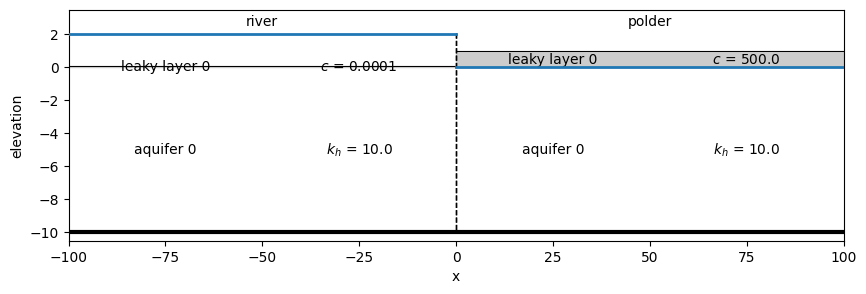

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_ylim(-10.5, 3.5)
ml_s.plots.xsection(
    xy=([-100, 0], [100, 0]), names=True, labels=True, params=True, ax=ax
);

Select 3 head observations that we will use in our calibration.

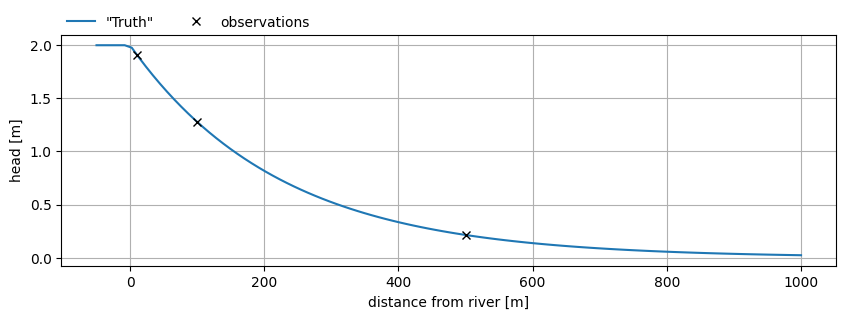

In [4]:
x = np.linspace(-50, 1000, 101)
h0 = ml_s.headalongline(x=x, y=np.zeros_like(x))

x_obs = [10, 100, 500]
h_obs = ml_s.headalongline(x=x_obs, y=np.zeros_like(x_obs))[0]

plt.figure(figsize=(10, 3))
plt.plot(x, h0[0], label='"Truth"')
plt.plot(x_obs, h_obs, "kx", label="observations")
plt.legend(loc=(0, 1), frameon=False, ncol=2)
plt.ylabel("head [m]")
plt.xlabel("distance from river [m]")
plt.grid()

Perform the calibration. We are using the same model we created before, but we are
purposely setting the initial parameter estimates to different values. 

In [5]:
cal = tf.Calibrate(steady_model=ml_s)

for i in range(len(x_obs)):
    cal.add_steady_head(name=f"obs{i}", x=x_obs[i], y=0.0, layer=[0], h=h_obs[i])

cal.set_aquifer_parameter("kaq", layers=[0], initial=2.0, inhoms=["river", "polder"])
cal.set_aquifer_parameter("c", layers=[0], initial=10.0, inhoms=["polder"])

cal.fit()

..................................................................................................................................................................................................................................................................................................................................................................................................................................................................................
                      initial     optimal  pmin  pmax  log_scaled  n_targets  \
name                                                                           
kaq_0_0_river_polder      2.0    9.999999  -inf   inf       False          2   
c_0_0_polder             10.0  500.000035  -inf   inf       False          1   

                      n_models  n_inhoms  
name                                      
kaq_0_0_river_polder         1         2  
c_0_0_polder                 1         1  
RMSE: 1.392e-08


View the parameters dataframe:

In [6]:
cal.parameters.style.format(formatter="{:.2f}", subset=["initial", "optimal"])

,initial,optimal,pmin,pmax,log_scaled,n_targets,n_models,n_inhoms
name,,,,,,,,
kaq_0_0_river_polder,2.00,10.00,-inf,inf,False,2,1,2
c_0_0_polder,10.00,500.00,-inf,inf,False,1,1,1


Plot the results and compare to the truth.

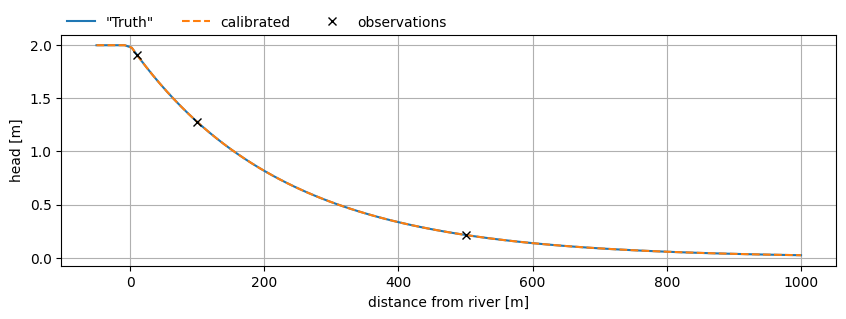

In [7]:
hc = ml_s.headalongline(x=x, y=np.zeros_like(x))

plt.figure(figsize=(10, 3))
plt.plot(x, h0[0], label='"Truth"')
plt.plot(x, hc[0], ls="dashed", label="calibrated")
plt.plot(x_obs, h_obs, "kx", label="observations")
plt.legend(loc=(0, 1), frameon=False, ncol=3)
plt.ylabel("head [m]")
plt.xlabel("distance from river [m]")
plt.grid()

## Transient calibration

In this section, we will test the calibration of a transient model with a sudden rise
of 2 m in river water level after t=0.1 days.

In [8]:
ml_t = tft.ModelXsection(naq=1, tmin=1e-3, tmax=100)

river_t = tft.XsectionMaq(
    ml_t,
    x1=-np.inf,
    x2=0.0,
    kaq=[10.0],
    z=[0.1, 0, -10],
    c=[1e-4],
    Saq=[1e-3],
    topboundary="semi",
    tsandhstar=[(0.1, 2)],
    name="river",
)

polder_t = tft.XsectionMaq(
    ml_t,
    x1=0.0,
    x2=np.inf,
    kaq=[10.0],
    z=[1, 0, -10],
    c=[500],
    Saq=[1e-3],
    topboundary="semi",
    name="polder",
)
ml_t.solve()

self.neq  2
solution complete


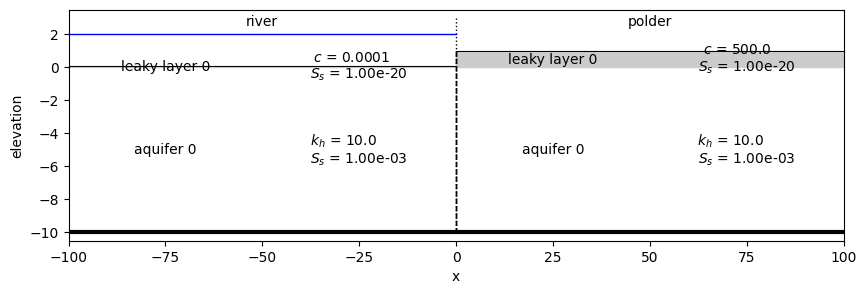

In [9]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.set_ylim(-10.5, 3.5)
ml_t.plots.xsection(
    xy=([-100, 0], [100, 0]),
    names=True,
    labels=True,
    params=True,
    ax=ax,
    sep="\n",
    hstar=2.0,
);

Plot the head over time along the cross-section. We will extract the heads at the three
observation points we used earlier as our observation time series.

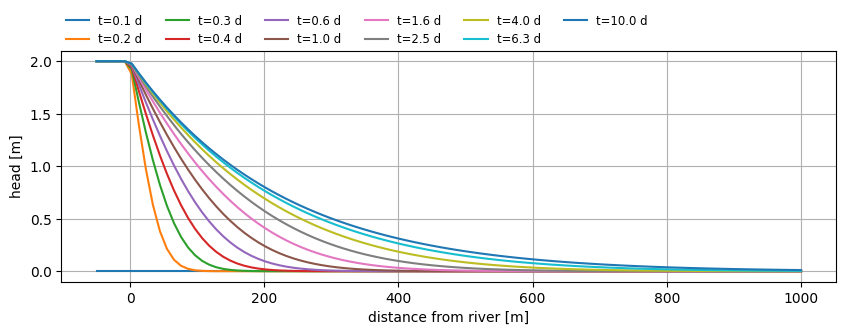

In [10]:
t = np.logspace(-1, 1, 11)
h0 = ml_t.headalongline(x=x, y=np.zeros_like(x), t=t)

plt.figure(figsize=(10, 3))
for i in range(len(t)):
    plt.plot(x, h0[0, i], label=f"t={t[i]:.1f} d")
plt.legend(loc=(0, 1), frameon=False, ncol=6, fontsize="small")
plt.ylabel("head [m]")
plt.xlabel("distance from river [m]")
plt.grid()

Plot our observation data. Note the log-scale of the x-axis.

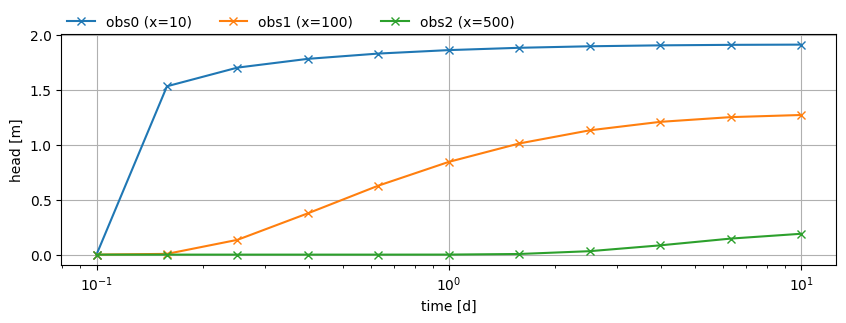

In [11]:
h_obs_series = ml_t.headalongline(x=x_obs, y=np.zeros_like(x_obs), t=t)

plt.figure(figsize=(10, 3))
for i in range(len(x_obs)):
    plt.plot(t, h_obs_series[0, :, i], label=f"obs{i} (x={x_obs[i]})", marker="x")
plt.legend(loc=(0, 1), frameon=False, ncol=3)
plt.ylabel("head [m]")
plt.xlabel("time [d]")
plt.xscale("log")
plt.grid()

Create the calibration class, add the observation time series, set the calibration
parameters, and calibrate the model.

In [12]:
cal = tf.Calibrate(transient_model=ml_t)

for i in range(len(x_obs)):
    cal.add_head_time_series(
        name=f"obs{i}", x=x_obs[i], y=0.0, layer=[0], t=t, h=h_obs_series[0, :, i]
    )

cal.set_aquifer_parameter("kaq", layers=[0], initial=2.0, inhoms=["river", "polder"])
cal.set_aquifer_parameter("c", layers=[0], initial=10.0, inhoms=["polder"])
cal.set_aquifer_parameter("Saq", layers=[0], initial=1e-4, inhoms=["polder"])

cal.fit()

.........................................................................................................................................................................................................................................................................................................................................................................................
                      initial     optimal  pmin  pmax  log_scaled  n_targets  \
name                                                                           
kaq_0_0_river_polder   2.0000   10.000424  -inf   inf       False          2   
c_0_0_polder          10.0000  499.978787  -inf   inf       False          1   
Saq_0_0_polder         0.0001    0.001000  -inf   inf       False          1   

                      n_models  n_inhoms  
name                                      
kaq_0_0_river_polder         1         2  
c_0_0_polder                 1         1  
Saq_0_0_polder               1         1  
RMSE: 

In [13]:
cal.parameters.style.format(formatter="{:.2e}", subset=["initial", "optimal"])

,initial,optimal,pmin,pmax,log_scaled,n_targets,n_models,n_inhoms
name,,,,,,,,
kaq_0_0_river_polder,2.00e+00,1.00e+01,-inf,inf,False,2,1,2
c_0_0_polder,1.00e+01,5.00e+02,-inf,inf,False,1,1,1
Saq_0_0_polder,1.00e-04,1.00e-03,-inf,inf,False,1,1,1


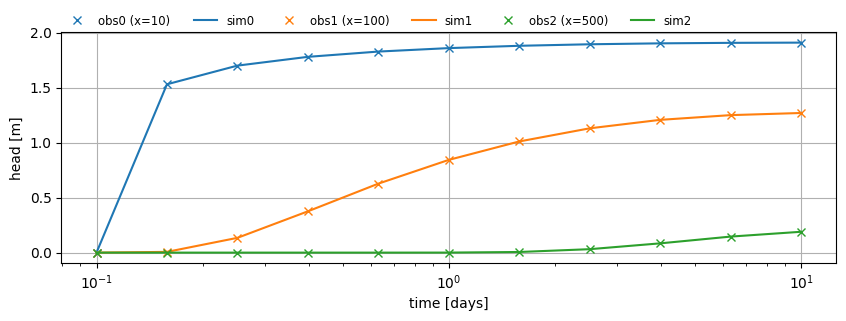

In [14]:
plt.figure(figsize=(10, 3))
hm = ml_t.headalongline(x=x_obs, y=np.zeros_like(x_obs), t=t)
for i in range(len(x_obs)):
    plt.plot(
        t, h_obs_series[0, :, i], label=f"obs{i} (x={x_obs[i]})", marker="x", ls="none"
    )
    plt.plot(t, hm[0, :, i], label=f"sim{i}", color=f"C{i}")

plt.xscale("log")
plt.legend(loc=(0, 1), frameon=False, ncol=6, fontsize="small")
plt.xlabel("time [days]")
plt.ylabel("head [m]")
plt.grid()

## Combined calibration

Next, we want to attempt a combined calibration. This is done by superposition of a
steady model, representing the average situation (i.e. the average river stage), and a
transient model that captures the effect of a sudden change in the river water level.
The average river stage is 2 m+ref, the sudden rise is 2m at t=0.1 days.

We build 2 models, a steady and transient model. Note that we give the `XSection`
elements the same names in both models. This allows the calibration class to share
parameters between zones (e.g. the polder) across both models.

The steady model is added to the transient model. This means the transient model will
use the steady model to compute heads and flows: $h = h_\text{steady} + h_\text{transient}$.

In [15]:
ml_s = tfs.ModelXsection(naq=1)
river_s = tfs.XsectionMaq(
    ml_s,
    x1=-np.inf,
    x2=0.0,
    kaq=[10.0],
    z=[1, 0, -10],
    c=[1e-4],
    npor=0.3,
    topboundary="semi",
    hstar=2,
    name="river",
)

polder_s = tfs.XsectionMaq(
    ml_s,
    x1=0.0,
    x2=np.inf,
    kaq=[10.0],
    z=[1, 0, -10],
    c=[500],
    npor=0.3,
    topboundary="semi",
    hstar=0,
    name="polder",
)

# add steady model to transient model
ml_t = tft.ModelXsection(naq=1, tmin=1e-3, tmax=100, steady=ml_s)

river_t = tft.XsectionMaq(
    ml_t,
    x1=-np.inf,
    x2=0.0,
    kaq=[10.0],
    z=[1, 0, -10],
    c=[1e-4],
    Saq=[1e-3],
    topboundary="semi",
    tsandhstar=[(0.1, 2)],
    name="river",
)

polder_t = tft.XsectionMaq(
    ml_t,
    x1=0.0,
    x2=np.inf,
    kaq=[10.0],
    z=[1, 0, -10],
    c=[500],
    Saq=[1e-3],
    topboundary="semi",
    name="polder",
)
ml_t.solve()

Number of elements, Number of equations: 4 , 2
....
solution complete
self.neq  2
solution complete


Plot the change in head over time.

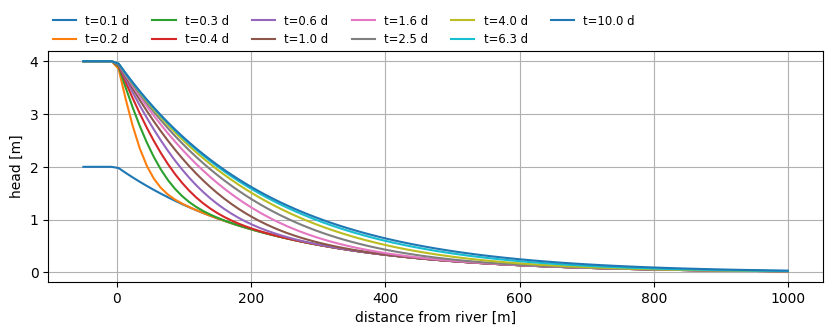

In [16]:
t = np.logspace(-1, 1, 11)
h0 = ml_t.headalongline(x=x, y=np.zeros_like(x), t=t)

plt.figure(figsize=(10, 3))
for i in range(len(t)):
    plt.plot(x, h0[0, i], label=f"t={t[i]:.1f} d")
plt.legend(loc=(0, 1), frameon=False, ncol=6, fontsize="small")
plt.ylabel("head [m]")
plt.xlabel("distance from river [m]")
plt.grid()

Now we get our head time series from the model to use as our observation time series in
the calibration.

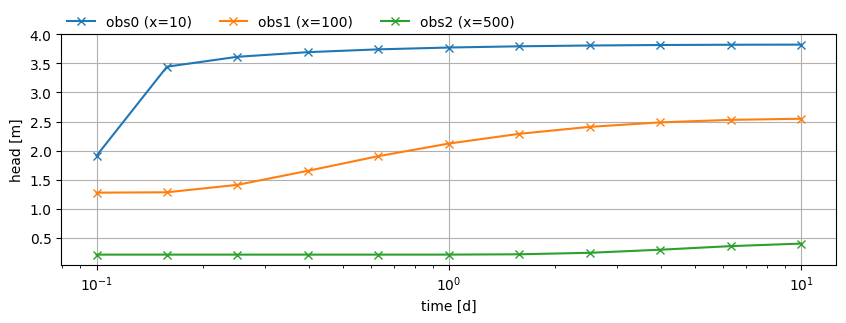

In [17]:
h_obs_series = ml_t.headalongline(x=x_obs, y=np.zeros_like(x_obs), t=t)

plt.figure(figsize=(10, 3))
for i in range(len(x_obs)):
    plt.plot(t, h_obs_series[0, :, i], label=f"obs{i} (x={x_obs[i]})", marker="x", ls="-")
plt.legend(loc=(0, 1), frameon=False, ncol=3)
plt.ylabel("head [m]")
plt.xlabel("time [d]")
plt.grid()
plt.xscale("log")

Now we will calibrate both models simultaneously by passing both models to the
calibrate class. We need to add the steady model separately so that the calibration
class can link the parameters between the models.

We add the head observations as before. 

Note that when defining the calibration parameters, we can now set the names of the
`XSections` we want to target, as well as the `model`. The `model` can be `"steady"`,
`"transient"` or `"both"`.

In [18]:
cal = tf.Calibrate(transient_model=ml_t, steady_model=ml_s)

for i in range(len(x_obs)):
    cal.add_head_time_series(
        name=f"obs{i}", x=x_obs[i], y=0.0, layer=[0], t=t, h=h_obs_series[0, :, i]
    )

cal.set_aquifer_parameter(
    "kaq",
    layers=[0],
    initial=2.0,
    pmin=2.0,
    pmax=100.0,
    inhoms=["polder"],
    model="both",
)
cal.set_aquifer_parameter(
    "c",
    layers=[0],
    initial=1000.0,
    pmin=1.0,
    pmax=10_000,
    inhoms=["polder"],
    model="both",
)
cal.set_aquifer_parameter(
    "Saq",
    layers=[0],
    initial=1e-4,
    inhoms=["polder"],
    pmin=1e-10,
    pmax=1.0,
    model="transient",
    log_scale=True,
)

# cal.lmfit()
cal.fit()

.............................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................
                  initial     optimal          pmin     pmax  log_scaled  \
name                                                                       
kaq_0_0_polder     2.0000    9.999954  2.000000e+00    100.0       False   
c_0_0_polder    1000.0000  500.002305  1.000000e+00  10000.0       False   
Saq_0_0_polder     0.0001    0.001000  1.000000e-10      1.0        True   

                n_targets  n_models  n_inhoms

Let's view the parameters dataframe

In [19]:
cal.parameters.style.format(
    formatter="{:.2e}", subset=["initial", "optimal", "pmin", "pmax"]
)

,initial,optimal,pmin,pmax,log_scaled,n_targets,n_models,n_inhoms
name,,,,,,,,
kaq_0_0_polder,2.00e+00,1.00e+01,2.00e+00,1.00e+02,False,2,2,1
c_0_0_polder,1.00e+03,5.00e+02,1.00e+00,1.00e+04,False,2,2,1
Saq_0_0_polder,1.00e-04,1.00e-03,1.00e-10,1.00e+00,True,1,1,1


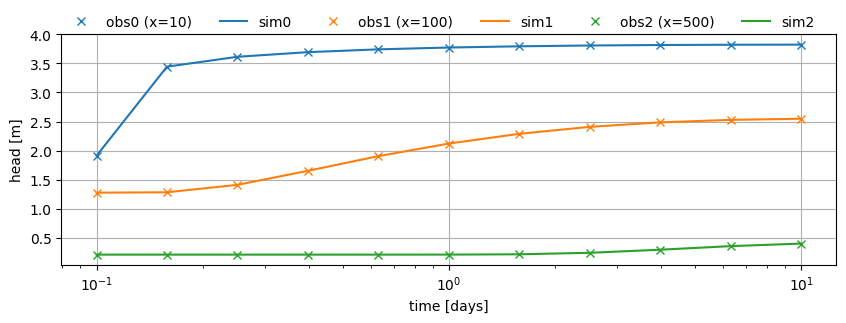

In [20]:
plt.figure(figsize=(10, 3))
hm = ml_t.headalongline(x=x_obs, y=np.zeros_like(x_obs), t=t)
for i in range(len(x_obs)):
    plt.plot(
        t, h_obs_series[0, :, i], label=f"obs{i} (x={x_obs[i]})", marker="x", ls="none"
    )
    plt.plot(t, hm[0, :, i], label=f"sim{i}", color=f"C{i}")

plt.xscale("log")
plt.legend(loc=(0, 1), frameon=False, ncol=6)
plt.xlabel("time [days]")
plt.ylabel("head [m]")
plt.grid()

## Calibrating on time series with constant offsets

The Calibrate class supports adding unknown constants for each head time series. This
is useful when the data has been measured relative to some reference level, but we are
only interested in the variation in heads. This could be used for calibrating to head
changes, while ignoring the absolute levels. Or, it could be used to calibrate on head
observations that lie along a river, where the reference level might change slightly
as we move downstream along that river.

In this example, we're simply adding an increasing constant value (1, 2 or 3 m) to
each head observation from the previous example.

Note that when adding the head time series, we now specify the constant and provide it
with a tuple containing three values: `constant = (initial, pmin, pmax)`. This
represents the initial guess of the reference level, and the upper and lower bounds.
The upper and lower bounds are optional and may be ommitted by passing a single float.

In [21]:
cal = tf.Calibrate(transient_model=ml_t, steady_model=ml_s)

for i in range(len(x_obs)):
    cal.add_head_time_series(
        name=f"obs{i}",
        x=x_obs[i],
        y=0.0,
        layer=[0],
        t=t,
        h=h_obs_series[0, :, i] + (i + 1.0),
        constant=(0.1, -10, 10),
    )

cal.set_aquifer_parameter(
    "kaq",
    layers=[0],
    initial=2.0,
    pmin=2.0,
    pmax=100.0,
    inhoms=["polder"],
    model="both",
)
cal.set_aquifer_parameter(
    "c",
    layers=[0],
    initial=1000.0,
    pmin=1.0,
    pmax=10_000,
    inhoms=["polder"],
    model="both",
)
cal.set_aquifer_parameter(
    "Saq",
    layers=[0],
    initial=1e-4,
    inhoms=["polder"],
    pmin=1e-10,
    pmax=1.0,
    model="transient",
    log_scale=True,
)

# cal.lmfit()
cal.fit()

........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

The parameters dataframe shows that we were able to get the correct values of the
constants.

In [22]:
cal.parameters.style.format(
    formatter="{:.2f}", subset=["initial", "optimal", "pmin", "pmax"]
)

,initial,optimal,pmin,pmax,log_scaled,n_targets,n_models,n_inhoms
name,,,,,,,,
obs0_constant,0.10,1.00,-10.00,10.00,False,1,0,0
obs1_constant,0.10,2.00,-10.00,10.00,False,1,0,0
obs2_constant,0.10,3.00,-10.00,10.00,False,1,0,0
kaq_0_0_polder,2.00,10.00,2.00,100.00,False,2,2,1
c_0_0_polder,1000.00,500.01,1.00,10000.00,False,2,2,1
Saq_0_0_polder,0.00,0.00,0.00,1.00,True,1,1,1


Plot the calibration results. We now use the head time series objects contained within
the Calibration class to plot the observations. When we apply the constants, we see the
model fits perfectly with the data. If we set `apply_constant=False`, we would see that
the observations are shifted vertically relative to the model simulation.

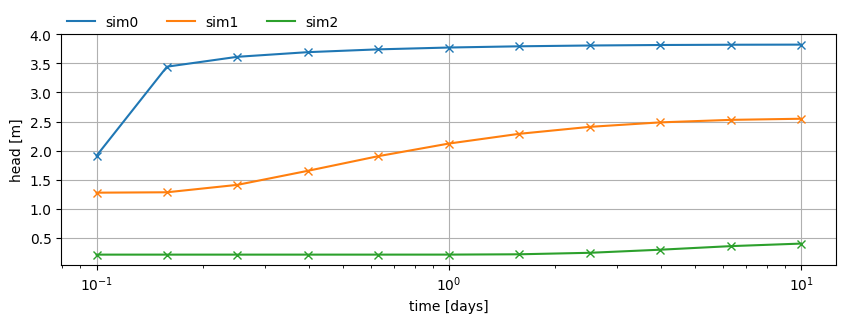

In [23]:
plt.figure(figsize=(10, 3))
hm = ml_t.headalongline(x=x_obs, y=np.zeros_like(x_obs), t=t)
for i in range(len(x_obs)):
    cal.observations_dict[f"obs{i}"].plot(
        ax=plt.gca(), marker="x", ls="none", apply_constant=True
    )
    plt.plot(t, hm[0, :, i], label=f"sim{i}", color=f"C{i}")

plt.xscale("log")
plt.legend(loc=(0, 1), frameon=False, ncol=6)
plt.xlabel("time [days]")
plt.ylabel("head [m]")
plt.grid()

## Calibrating on time series with time shifts

Another option the new Calibration class provides is to set time shift parameters in the calibration. This allows the optimization to shift the head time series in time. This can be useful when there are phase shifts in the data that are not represented in our model, e.g. when the observations lie along a river, where a flood wave might arrive slightly earlier in upstream observation wells relative to the downstream observation wells. 

In this example, we're simply adding an increasing time shift (0.1, 0.2 and 0.3 days) to
each head observation series from the previous example.

Note that when adding the head time series, we now specify the time shift and provide it
with a tuple containing three values: `time_shift = (initial, pmin, pmax)`. This
represents the initial guess of the time shift, and the upper and lower bounds.
The upper and lower bounds are optional and may be ommitted by passing a single float.

We recreate the transient cross-section model here to reduce the order of the `tmin`
parameter, because shifting the observation time series can cause observations to lie
close to the changes in boundary conditions, which will introduce NaNs into the
simulation. These are filtered out, but the optimization might still be affected, so it
is recommended to also reduce the `tmin` to avoid this as much as possible.

In [24]:
# add steady model to transient model
ml_t = tft.ModelXsection(naq=1, tmin=1e-6, tmax=100, steady=ml_s)

river_t = tft.XsectionMaq(
    ml_t,
    x1=-np.inf,
    x2=0.0,
    kaq=[10.0],
    z=[1, 0, -10],
    c=[1e-4],
    Saq=[1e-3],
    topboundary="semi",
    tsandhstar=[(0.1, 2)],
    name="river",
)

polder_t = tft.XsectionMaq(
    ml_t,
    x1=0.0,
    x2=np.inf,
    kaq=[10.0],
    z=[1, 0, -10],
    c=[500],
    Saq=[1e-3],
    topboundary="semi",
    name="polder",
)
ml_t.solve()

Number of elements, Number of equations: 4 , 2
....
solution complete
self.neq  2
solution complete


In [25]:
cal = tf.Calibrate(transient_model=ml_t, steady_model=ml_s)

for i in range(len(x_obs)):
    cal.add_head_time_series(
        name=f"obs{i}",
        x=x_obs[i],
        y=0.0,
        layer=[0],
        t=t + 0.1 * (i + 1),
        h=h_obs_series[0, :, i],
        time_shift=(1 / 24.0, 0.0, 1.0),  # initial guess is we're 1 hour off
    )

cal.set_aquifer_parameter(
    "kaq",
    layers=[0],
    initial=2.0,
    pmin=2.0,
    pmax=100.0,
    inhoms=["polder"],
    model="both",
)
cal.set_aquifer_parameter(
    "c",
    layers=[0],
    initial=1000.0,
    pmin=1.0,
    pmax=10_000,
    inhoms=["polder"],
    model="both",
)
cal.set_aquifer_parameter(
    "Saq",
    layers=[0],
    initial=1e-4,
    inhoms=["polder"],
    pmin=1e-10,
    pmax=1.0,
    model="transient",
    log_scale=True,
)

# cal.lmfit()
cal.fit()

........................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

We got a few warnings about the computation time lying to close to a change in boundary
condition, but the results looks good nonetheless. The parameters dataframe shows the
time shifts are estimated correctly.

In [26]:
cal.parameters.style.format(
    formatter="{:.2f}", subset=["initial", "optimal", "pmin", "pmax"]
)

,initial,optimal,pmin,pmax,log_scaled,n_targets,n_models,n_inhoms
name,,,,,,,,
obs0_time_shift,0.04,0.10,0.00,1.00,False,1,0,0
obs1_time_shift,0.04,0.20,0.00,1.00,False,1,0,0
obs2_time_shift,0.04,0.30,0.00,1.00,False,1,0,0
kaq_0_0_polder,2.00,9.98,2.00,100.00,False,2,2,1
c_0_0_polder,1000.00,500.80,1.00,10000.00,False,2,2,1
Saq_0_0_polder,0.00,0.00,0.00,1.00,True,1,1,1


Plot the calibration results. We now use the head time series objects contained within
the Calibration class to plot the observations. When we apply the time shifts, we see the
model fits perfectly with the data. If we set `apply_time_shift=False`, we would see that
the observations are shifted in time relative to the model simulation.

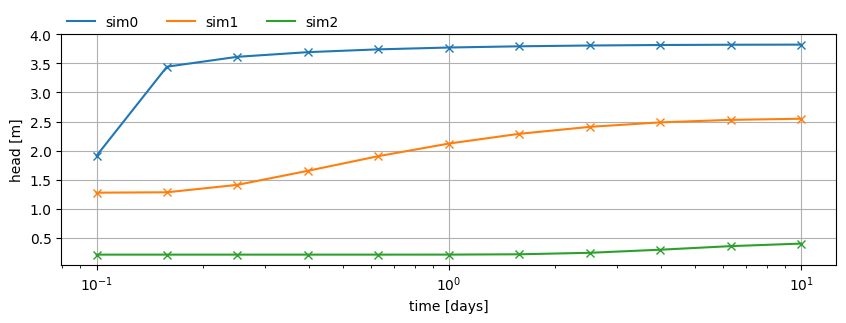

In [27]:
plt.figure(figsize=(10, 3))
hm = ml_t.headalongline(x=x_obs, y=np.zeros_like(x_obs), t=t)
for i in range(len(x_obs)):
    cal.observations_dict[f"obs{i}"].plot(
        ax=plt.gca(), marker="x", ls="none", apply_time_shift=True
    )
    plt.plot(t, hm[0, :, i], label=f"sim{i}", color=f"C{i}")

plt.xscale("log")
plt.legend(loc=(0, 1), frameon=False, ncol=6)
plt.xlabel("time [days]")
plt.ylabel("head [m]")
plt.grid()